In [ ]:
# CHANGE THE SETUP FUNCTION!! (Is quite unprofessional - it was previously created to allow easy work in notebooks)

"""
Connectome Preprocessing Pipeline.

This script includes the following steps: 
    - Computes distance matrix
    - Loads individual connectomes, thresholds them at specified goal densities (a hyperparameter - can be passed with --goal-densities 1 2 3 ...) 
    - Computes graph measures (if analyzing a single density, use --analyze-density 10) 
    - Loads ROI identifiers
    - Builds structural consensus connectomes
    - Optionally plots/saves illustrative figures


Usage examples: 
    - Run end-to-end with default settings (multiple densities): 
        python connectome_preprocessing_pipeline.py
        
    - Run with a single density (hyperparameter) and disable plotting:
        python connectome_preprocessing_pipeline.py --goal-densities 14 --no-plots
        
    - Change resolution and choose which density to analyze for graph measures:
        python connectome_preprocessing_pipeline.py \
          --resolution 68 \
          --goal-densities 10 12 14 16 18 20 \
          --analyze-density 12


Notes: 
    - (Based on 01_preprocessing.ipynb)
    - Paths are taken from `notebook_setup.setup()`. 
    - Heavy intermediate results are cached to disk to avoid recomputation.  
"""


from __future__ import annotations

import argparse
import sys
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import bct
from netneurotools.networks import threshold_network, struct_consensus


# Local imports from your codebase
# from notebook_setup import setup
from src.preprocessing.preprocess_distance_matrix import get_distance_matrix_from_coords, get_distance_matrix_from_fiber_lengths
from src.structural_analysis.graph_measures import analyze_connectomes

from src.preprocessing.preprocessing_setup import setup
from src.preprocessing.process_01_consensus_networks import threshold_to_density


from src.preprocessing.utils import setup_paths, save_numpy, save_dataframe # TODO: Remove this again, not needed. 

# Config & argument parsing
@dataclass
class PipelineConfig:
    resolution: int = 68
    goal_densities: Tuple[int, ...] = (10, 12, 14, 16, 18, 20)  # in percent
    analyze_density: int = 10  # used for steps requiring a single binarized set
    do_plots: bool = False # True

    # Communication model and rich-club options for graph measures
    comm_mode: str = "estrada_scaled"
    rich_nodes_global: Optional[np.ndarray] = None
    rich_top_percent: float = 0.20


def parse_args() -> PipelineConfig:
    p = argparse.ArgumentParser(description="Connectome preprocessing pipeline")
    p.add_argument("--resolution", type=int, default=68, # CHANGE here
                   help="Parcellation resolution for distance matrix & inputs (default: 68)")
    p.add_argument("--goal-densities", type=int, nargs="+",
                   default=[10, 12, 14, 16, 18, 20],
                   help="One or more goal densities in PERCENT to retain during thresholding")
    p.add_argument("--analyze-density", type=int, default=10,
                   help="Which density (in percent) to use for analyses that require a single binarized set")
    p.add_argument("--do_plots", action="store_true",
                   help="Activate plotting (only save data)")
    p.add_argument("--comm-mode", type=str, default="estrada_scaled",
                   help="Communication model used in analyze_connectomes (default: estrada_scaled)")
    p.add_argument("--rich-top-percent", type=float, default=0.20,
                   help="Top fraction for rich club node selection (default: 0.20)")

    args = p.parse_args()

    return PipelineConfig(
        resolution=args.resolution,
        goal_densities=tuple(args.goal_densities),
        analyze_density=args.analyze_density,
        do_plots=args.do_plots,
        comm_mode=args.comm_mode,
        rich_top_percent=args.rich_top_percent,
    )

cfg = PipelineConfig(
        resolution=50, # args.resolution,
        goal_densities=[10], # tuple(args.goal_densities),
        analyze_density=10, # args.analyze_density,
        do_plots=True, # args.do_plots,
        comm_mode="estrada_scaled", # args.comm_mode,
        rich_top_percent=0.2) 


paths = setup_paths(dataset_name="suarez_MaMI_dataset") 
    
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/src/preprocessing


In [63]:
paths


{'path_raw_data': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset'),
 'path_00_preprocessed': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/00_preprocessed'),
 'path_01_connectomes': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes'),
 'path_02_distance_matrices': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices'),
 'path_03_graph_measures': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/03_graph_measures'),
 'path_04_further_info': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info'),
 'path_output_for_logs_and_plots': PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4

In [65]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import cdist

def reduce_nodes(connection_matrix, coordinates, resolution=100):
    """
    Reduce nodes in a brain connectivity matrix by merging closest pairs.
    
    Args:
        connection_matrix: (200, 200) connectivity matrix
        coordinates: (200, 3) node coordinates
        n_target: target number of nodes (default 100)
    
    Returns:
        new_matrix: (n_target, n_target) reduced connectivity matrix
        new_coords: (n_target, 3) reduced coordinates
    """
    n_nodes = len(coordinates)
    n_per_half = n_nodes // 2
    n_target_per_half = resolution // 2
    
    # Process each hemisphere
    new_coords_list = []
    merge_maps = []
    
    for half_idx in range(2):
        start_idx = half_idx * n_per_half
        end_idx = start_idx + n_per_half
        
        # Get hemisphere data
        coords_half = coordinates[start_idx:end_idx].copy()
        active = np.ones(n_per_half, dtype=bool)
        merge_map = np.arange(n_per_half)
        
        # Merge nodes until target reached
        n_to_merge = n_per_half - n_target_per_half
        for _ in range(n_to_merge):
            active_indices = np.where(active)[0]
            active_coords = coords_half[active_indices]
            
            # Find closest pair
            distances = cdist(active_coords, active_coords)
            np.fill_diagonal(distances, np.inf)
            i, j = np.unravel_index(distances.argmin(), distances.shape)
            idx_i, idx_j = active_indices[i], active_indices[j]
            
            # Merge: keep idx_i, remove idx_j
            coords_half[idx_i] = (coords_half[idx_i] + coords_half[idx_j]) / 2
            active[idx_j] = False
            merge_map[merge_map == idx_j] = idx_i
        
        new_coords_list.append(coords_half[active])
        merge_maps.append(merge_map + start_idx)
    
    # Combine hemispheres
    new_coords = np.vstack(new_coords_list)
    full_merge_map = np.concatenate(merge_maps)
    
    # Build new connectivity matrix
    new_matrix = np.zeros((resolution, resolution))
    for i in range(resolution):
        for j in range(resolution):
            mask_i = (full_merge_map == full_merge_map[i])
            mask_j = (full_merge_map == full_merge_map[j])
            new_matrix[i, j] = connection_matrix[np.ix_(mask_i, mask_j)].mean()
    
    return new_matrix, new_coords


# Setup paths
base_path = paths["path_raw_data"] / "connectivity/mami"
conn_dir = base_path / "conn_100"
coords_dir = base_path / "coords"

# Intermediate paths 
output_conn_dir = paths["path_00_preprocessed"] / "connectomes_downsampled_to_50"
output_coords_dir = paths["path_00_preprocessed"] / "coords_downsampled_to_50"
output_results_dir = paths["path_output_for_logs_and_plots"] / "results"
output_dist_dir = paths["path_00_preprocessed"] / "dis_matrices_downsampled_to_50" # paths["path_02_distance_matrices"] 

resolution = 100 # final resolution

# Create output directories
output_conn_dir.mkdir(exist_ok=True)
output_coords_dir.mkdir(exist_ok=True)
output_results_dir.mkdir(exist_ok=True)
output_dist_dir.mkdir(exist_ok=True)

# Get all animal names
animal_files = list(conn_dir.glob("*.npy"))
animal_names = [f.stem for f in animal_files]

# Storage for combined arrays and all results
all_conn = []
all_dist = []
all_results = []

# Process each animal
for name in animal_names:
    print(f"Processing {name}...")
    
    # Load data
    connection_matrix = np.load(conn_dir / f"{name}.npy")
    coordinates = np.load(coords_dir / f"{name}.npy")
    
    # Reduce resolution
    new_matrix, new_coords = reduce_nodes(connection_matrix, coordinates, resolution=100)
    
    # Calculate distance matrix
    distance_matrix = cdist(new_coords, new_coords)
    
    # Save individual files
    np.save(output_conn_dir / f"{name}.npy", new_matrix)
    np.save(output_coords_dir / f"{name}.npy", new_coords)
    np.save(output_dist_dir / f"{name}.npy", distance_matrix)
        
    # Analyze connectome
    results = analyze_connectomes(
        new_matrix[np.newaxis, :, :],  # Shape: (1, 100, 100)
        distance_matrix,
        comm_mode="estrada_scaled"
    )
    
    # Add animal name to results
    for result in results:
        result['animal'] = name
        all_results.append(result)
    
    # Store for combined arrays
    all_conn.append(new_matrix)
    all_dist.append(distance_matrix)

# Save combined arrays
all_conn = np.stack(all_conn)  # Shape: (num_animals, 100, 100)
all_dist = np.stack(all_dist)  # Shape: (num_animals, 100, 100)

np.save(paths["path_01_connectomes"] / f"00_connectomes_{resolution}.npy", all_conn)
np.save( paths["path_02_distance_matrices"] / f"distance_matrix_{resolution}.npy", all_dist)

# Save results as CSV
results_df = pd.DataFrame(all_results)
results_df.to_csv(paths["path_03_graph_measures"] / f"df_graph_measures_{resolution}.csv", index=False)

only_names_df = results_df["animal"]
only_names_df.to_csv(paths["path_04_further_info"] / f"names_of_animals_with_preprocessed_connectomes_{resolution}.csv")

print(f"\nProcessed {len(animal_names)} animals")
print(f"Combined connectivity shape: {all_conn.shape}")
print(f"Combined distances shape: {all_dist.shape}")
print(f"Results saved to: {paths["path_03_graph_measures"] / f"df_graph_measures_{resolution}.csv"}")
print(f"Results shape: {results_df.shape}")

Processing Rat4...
Processing Mouse...
Processing Meerkat4...
Processing CapraNubiana3...
Processing Oryx1...
Processing CapraNubiana2...
Processing Meerkat5...
Processing Rat5...
Processing Colobus2...
Processing ThomsonGazelle...
Processing CommonFox...
Processing PteropusLylei...
Processing Oryx2...
Processing Oryx3...
Processing CapraNubiana1...
Processing HoneyBadger...
Processing Rat6...
Processing Marmoset...
Processing ChaerephonPlicata...
Processing Hyrax2...
Processing DikDik...
Processing Lama2...
Processing GreenMonkey1...
Processing Rat2...
Processing Meerkat2...
Processing Pecari2...
Processing TamarinCottonTop2...
Processing CapraNubiana4...
Processing Meerkat3...
Processing Rat3...
Processing Hyrax1...
Processing GreenMonkey2...
Processing Lama1...
Processing Rat1...
Processing Meerkat1...
Processing Pecari1...
Processing Rhinolophus...
Processing Merion...
Processing SquirrelMonkey1...
Processing TamarinCottonTop1...
Processing Giraffe1...
Processing RedNeckWallaby...


In [ ]:
def load_connectivity_matrices(connectome_dir: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Load all .npy files from connectome directory and stack them.
    Returns: (n_files, 100, 100),  DataFrame with columns ['name', 'file_path']
    """
    # Get all .npy files
    npy_files = sorted(connectome_dir.glob("*.npy"))
    
    if not npy_files:
        raise ValueError(f"No .npy files found in {connectome_dir}")
    
    # Load and stack matrices
    matrices = []
    names = []
    
    for file_path in npy_files:
        matrix = np.load(file_path)
        
        # Validate shape
        if matrix.shape != (100, 100):
            raise ValueError(f"{file_path.name} has shape {matrix.shape}, expected (100, 100)")
        
        matrices.append(matrix)
        names.append(file_path.stem)  # Gets filename without extension
    
    # Stack into single array
    stacked_matrices = np.stack(matrices, axis=0)
    
    # Create metadata dataframe
    metadata = pd.DataFrame({
        'found_name': names,
        'file_path': [str(f) for f in npy_files]
    })
    
    return stacked_matrices, metadata



In [ ]:
folder_to_search = paths["path_raw_data"] / "connectivity" / "mami" / f"conn_{cfg.resolution}"
matrices, df_metadata = load_connectivity_matrices(folder_to_search)

print(f"Loaded {len(matrices)} matrices")
print(f"Shape: {matrices.shape}")
print(f"\nFirst few species:\n{df_metadata.head()}")


Loaded 226 matrices
Shape: (226, 100, 100)

First few species:
         found_name                                          file_path
0             Addax  /Users/adrian/Documents/01_projects/14_4D_lab/...
1           Agouti1  /Users/adrian/Documents/01_projects/14_4D_lab/...
2           Agouti2  /Users/adrian/Documents/01_projects/14_4D_lab/...
3         Armadillo  /Users/adrian/Documents/01_projects/14_4D_lab/...
4  ArtibeusJamacien  /Users/adrian/Documents/01_projects/14_4D_lab/...


(array([1.963008e+06, 9.436200e+04, 5.461200e+04, 3.551200e+04,
        4.238200e+04, 1.338200e+04, 9.998000e+03, 7.868000e+03,
        6.328000e+03, 9.128000e+03, 3.480000e+03, 2.830000e+03,
        2.392000e+03, 3.748000e+03, 1.396000e+03, 1.208000e+03,
        9.960000e+02, 9.000000e+02, 1.452000e+03, 5.100000e+02,
        5.120000e+02, 4.420000e+02, 7.020000e+02, 3.120000e+02,
        2.600000e+02, 2.580000e+02, 2.020000e+02, 3.380000e+02,
        1.220000e+02, 1.280000e+02, 1.400000e+02, 1.980000e+02,
        8.800000e+01, 6.600000e+01, 9.000000e+01, 4.600000e+01,
        1.100000e+02, 3.400000e+01, 3.600000e+01, 3.800000e+01,
        7.000000e+01, 2.000000e+01, 2.800000e+01, 2.400000e+01,
        1.200000e+01, 2.800000e+01, 2.000000e+01, 2.000000e+01,
        1.600000e+01, 6.000000e+00, 1.400000e+01, 2.200000e+01,
        1.200000e+01, 4.000000e+00, 1.400000e+01, 6.000000e+00,
        4.000000e+00, 2.000000e+00, 2.000000e+00, 1.000000e+01,
        6.000000e+00, 2.000000e+00, 2.00

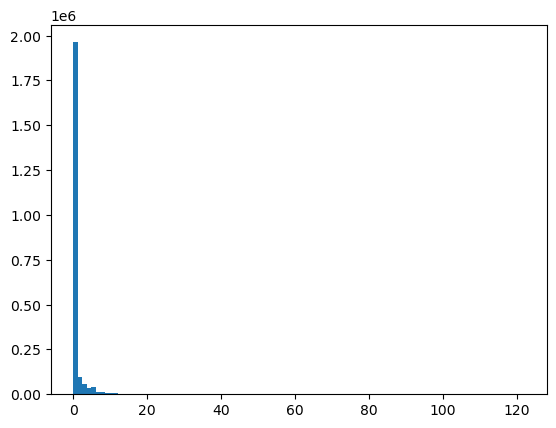

In [32]:
plt.hist(matrices.flatten(), bins=100)

In [33]:
save_path = paths["path_00_preprocessed"] / ""

In [35]:
df_further_info = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/info/info.csv")
df_further_info.head()

,Id,Super-Order,Order,Sub-Order,Family,Sub-Family,Genus,Species,Name,Common-Name,Filename
0,0,Laurasiatheria,Cetartiodactyla,Ruminantia,Bovidae,Hippotranginae,Addax,Addax Nasomaculatus,Addax,Addax,Addax
1,1,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,Agouti1
2,2,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,Agouti2
3,3,Xenarthra,Xenarthra,NaN,Chlamyphoridae,NaN,Chaetophractus,Chaetophractus villosus,Armadillo,Big hairy armadillo,Armadillo
4,4,Laurasiatheria,Chiroptera,Microchiroptera,Phyllostomidae,Stenodermatinae,Artibeus,Artibeus jamaicensis,Artibeus Jamacien,Jamaican fruit\rbat,ArtibeusJamacien


In [36]:
df_metadata.join(df_further_info)
merged_df = df_metadata.merge(df_further_info, left_on='found_name', right_on='Filename')


In [38]:
merged_df.keys()

Index(['found_name', 'file_path', 'Id', 'Super-Order', 'Order', 'Sub-Order',
       'Family', 'Sub-Family', 'Genus', 'Species', 'Name', 'Common-Name',
       'Filename'],
      dtype='object')

In [43]:
merged_df = merged_df.rename(columns={
    'Id': 'id',
    'Super-Order': 'super_order',
    'Order': 'order',
    'Sub-Order': 'sub_order',
    'Family': 'family',
    'Sub-Family': 'sub_family',
    'Genus': 'genus',
    'Species': 'species',
    'Name': 'name',
    'Common-Name': 'common_name',
    'Filename': 'filename'
})[['found_name', 'super_order', 'order', 'sub_order', 'family', 
    'sub_family', 'genus', 'species', 'name', 'common_name', 'filename', 'file_path']]

save_path = paths["path_04_further_info"] / "info_mamals.csv"
merged_df.to_csv(save_path)
print(save_path)


merged_df

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/info_mamals.csv


,found_name,super_order,order,sub_order,family,sub_family,genus,species,name,common_name,filename,file_path
0,Addax,Laurasiatheria,Cetartiodactyla,Ruminantia,Bovidae,Hippotranginae,Addax,Addax Nasomaculatus,Addax,Addax,Addax,/Users/adrian/Documents/01_projects/14_4D_lab/...
1,Agouti1,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,Agouti1,/Users/adrian/Documents/01_projects/14_4D_lab/...
2,Agouti2,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,Agouti2,/Users/adrian/Documents/01_projects/14_4D_lab/...
3,Armadillo,Xenarthra,Xenarthra,NaN,Chlamyphoridae,NaN,Chaetophractus,Chaetophractus villosus,Armadillo,Big hairy armadillo,Armadillo,/Users/adrian/Documents/01_projects/14_4D_lab/...
4,ArtibeusJamacien,Laurasiatheria,Chiroptera,Microchiroptera,Phyllostomidae,Stenodermatinae,Artibeus,Artibeus jamaicensis,Artibeus Jamacien,Jamaican fruit\rbat,ArtibeusJamacien,/Users/adrian/Documents/01_projects/14_4D_lab/...
...,...,...,...,...,...,...,...,...,...,...,...,...
211,Wilderbeest,Laurasiatheria,Cetartiodactyla,Ruminantia,Bovidae,Alcelaphinae,Connochaetes,Wilderbeest,Wilderbeest,Wilderbeest (gnu),Wilderbeest,/Users/adrian/Documents/01_projects/14_4D_lab/...
212,Wolf1,Laurasiatheria,Carnivora,Caniformia,Canidae,Caninae,Canis,Canis lupus,Wolf,Gray wolf,Wolf1,/Users/adrian/Documents/01_projects/14_4D_lab/...
213,Wolf2,Laurasiatheria,Carnivora,Caniformia,Canidae,Caninae,Canis,Canis lupus,Wolf,Gray wolf,Wolf2,/Users/adrian/Documents/01_projects/14_4D_lab/...
214,Wolf3,Laurasiatheria,Carnivora,Caniformia,Canidae,Caninae,Canis,Canis lupus,Wolf,Gray wolf,Wolf3,/Users/adrian/Documents/01_projects/14_4D_lab/...


In [ ]:
def load_dist_matrices(dist_dir: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Load all .npy files from connectome directory and stack them.
    Returns: (n_files, 100, 100),  DataFrame with columns ['name', 'file_path']
    """
    # Get all .npy files
    npy_files = sorted(dist_dir.glob("*.npy"))
    
    if not npy_files:
        raise ValueError(f"No .npy files found in {dist_dir}")
    
    # Load and stack matrices
    dist_matrices = []
    names = []
    
    for file_path in npy_files:
        coords = np.load(file_path)
        
        dist_mat = get_distance_matrix_from_coords(
            coords=coords,
            save_dir=paths["path_02_distance_matrices"], 
            resolution=cfg.resolution,
            plot=cfg.do_plots,
        )
        
        dist_matrices.append(dist_mat)
        names.append(file_path.stem)  # Gets filename without extension
    
    # Stack into single array
    stacked_dist_matrices = np.stack(matrices, axis=0)
    
    # Create metadata dataframe
    metadata = pd.DataFrame({
        'found_name': names,
        'file_path': [str(f) for f in npy_files]
    })
    
    return stacked_dist_matrices, metadata



In [ ]:
import numpy as np
from scipy.spatial.distance import cdist

def reduce_nodes(connection_matrix, coordinates, n_target=100):
    """
    Reduce nodes in a brain connectivity matrix by merging closest pairs.
    
    Args:
        connection_matrix: (200, 200) connectivity matrix
        coordinates: (200, 3) node coordinates
        n_target: target number of nodes (default 100)
    
    Returns:
        new_matrix: (n_target, n_target) reduced connectivity matrix
        new_coords: (n_target, 3) reduced coordinates
    """
    n_nodes = len(coordinates)
    n_per_half = n_nodes // 2
    n_target_per_half = n_target // 2
    
    # Process each hemisphere
    new_coords_list = []
    merge_maps = []
    
    for half_idx in range(2):
        # Get first and last node-index
        start_idx = half_idx * n_per_half
        end_idx = start_idx + n_per_half
        
        # Get hemisphere data
        coords_half = coordinates[start_idx:end_idx].copy()
        active = np.ones(n_per_half, dtype=bool)
        merge_map = np.arange(n_per_half)
        
        # Merge nodes until target reached
        n_to_merge = n_per_half - n_target_per_half
        for _ in range(n_to_merge):
            active_indices = np.where(active)[0]
            active_coords = coords_half[active_indices]
            
            # Find closest pair
            distances = cdist(active_coords, active_coords)
            np.fill_diagonal(distances, np.inf)
            i, j = np.unravel_index(distances.argmin(), distances.shape)
            idx_i, idx_j = active_indices[i], active_indices[j]
            
            # Merge: keep idx_i, remove idx_j
            coords_half[idx_i] = (coords_half[idx_i] + coords_half[idx_j]) / 2
            active[idx_j] = False
            merge_map[merge_map == idx_j] = idx_i
        
        new_coords_list.append(coords_half[active])
        merge_maps.append(merge_map + start_idx)
    
    # Combine hemispheres
    new_coords = np.vstack(new_coords_list)
    full_merge_map = np.concatenate(merge_maps)
    
    # Build new connectivity matrix
    new_matrix = np.zeros((n_target, n_target))
    for i in range(n_target):
        for j in range(n_target):
            # Find all original nodes mapping to new nodes i and j
            mask_i = (full_merge_map == full_merge_map[full_merge_map == full_merge_map[i]][0])
            mask_j = (full_merge_map == full_merge_map[full_merge_map == full_merge_map[j]][0])
            # Average connections
            new_matrix[i, j] = connection_matrix[np.ix_(mask_i, mask_j)].mean()
    
    return new_matrix, new_coords


# Example usage:
# new_matrix, new_coords = reduce_nodes(connection_matrix, coordinates)

In [59]:
connection_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_100/Zebra.npy")
coordinates = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/coords/Zebra.npy")

new_matrix, new_coords = reduce_nodes(connection_matrix, coordinates)

In [62]:
new_matrix.shape, new_coords.shape

((100, 100), (100, 3))

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_42731/2559810587.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(-np.log(d))


(200, 200)

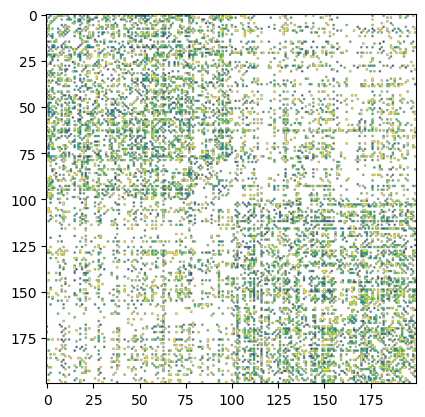

In [55]:
d = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_100/Baboon1.npy")
plt.imshow(-np.log(d))
d.shape

In [57]:
d.astype(bool).sum()/(d.shape[0]*(d.shape[0]-1))

np.float64(0.23477386934673367)

In [ ]:

# Distance matrix
dist_mat = get_distance_matrix_from_coords(
    paths=paths, 
    resolution=cfg.resolution,
    plot=cfg.do_plots,
)

In [ ]:




def get_individual_connectomes(raw_data_path, output_path): 
    """
    Get individual connectomes from 70 subjects
    """

    # Open the MAT-file as an HDF5 container. Loading with "sio.loadmat" does not work here, as the matlab version is too new (v7.3+).
    import h5py

    with h5py.File(raw_data_path, "r") as f:
        all_connectomes = np.array(f["M"]).T
        print("Data shape:", all_connectomes.shape) # (68, 68, 70) -> 68 regions, 68 regions, 70 subjects


    # Check the minimal value of all connectomes (to ensure no negative distances)
    print("Statistics of all connectomes:\n",
        "Min:", np.min(all_connectomes), "\n",
        "Max:", np.max(all_connectomes), "\n",
        "Mean:", np.mean(all_connectomes), "\n",
        "Std:", np.std(all_connectomes))


    # The connectomes sometimes have diagonal values that are not zero, so they are now set to zero
    for i in range(1, all_connectomes.shape[0]):
        all_connectomes[i,:,:][np.diag_indices_from(all_connectomes[i,:,:])] = 0.0
        # print(f"Checking connectome {i+1}...")
        # print(all_connectomes[i,:,:].shape)
        assert np.all(np.diag(all_connectomes[i,:,:]) == 0), "Diagonal of distance matrix is not zero!"

    # Sanity check:
    # - check if diagonal is zero for all connectomes
    for i in range(1, all_connectomes.shape[0]):
        assert np.all(np.diag(all_connectomes[i,:,:]) == 0), "Diagonal of distance matrix is not zero!"

    # Print information
    nsub, n, _ = all_connectomes.shape
    print(f"{nsub} subjects | {n} × {n} matrices")

    # Save the connectomes as numpy arrays
    np.save(output_path / f"all_connectomes_{n}.npy", all_connectomes)

    return all_connectomes, nsub, n



get_individual_connectomes


In [ ]:


# def step_load_individual_connectomes(paths: dict, resolution: int = 68) -> Tuple[np.ndarray, int, int]:
#     sc_mat_path = paths["INPUT_DATA_PATH"] / f"data_700mb_individual_connectomes/SC_{resolution}.mat"
#     all_connectomes, nsub, n = get_individual_connectomes(
#         raw_data_path=sc_mat_path,
#         output_path=paths["PREPROCESSED_PATH"],
#     )
#     return all_connectomes, nsub, n


# def step_threshold_connectomes(
#     all_connectomes: np.ndarray,
#     n: int,
#     goal_densities: Iterable[int],
#     save_dir: Path,
# ) -> None:
#     goal_densities = list(goal_densities)
#     for gd in goal_densities:
#         connectomes_binarized = np.array([
#             threshold_network(all_connectomes[i], retain=gd)
#             for i in range(len(all_connectomes))
#         ])
#         connectome_densities = np.array([
#             bct.density_und(connectomes_binarized[i])[0]
#             for i in range(len(connectomes_binarized))
#         ])
#         print(
#             f"Average density over {len(connectomes_binarized)} subjects: "
#             f"{np.mean(connectome_densities)*100:.3f}% (goal {gd}%)."
#         )
#         save_numpy(
#             save_dir / f"connectomes_binarized_{n}x{n}_density_{gd}_percent.npy",
#             connectomes_binarized,
#         )

#     # Save weighted set once
#     save_numpy(save_dir / f"connectomes_weighted_{n}.npy", all_connectomes)




# def step_consensus_connectomes(
#     paths: dict,
#     connectomes_binarized: np.ndarray,
#     all_connectomes: np.ndarray,
#     dist_mat: np.ndarray,
#     hemi_id: np.ndarray,
#     n: int,
#     analyze_density: int,
# ) -> Tuple[np.ndarray, np.ndarray, float, float]:
#     # Shapes expected by struct_consensus: nodes x nodes x subjects
#     # Our arrays are subjects x nodes x nodes, so we transpose with .T
#     consensus_conn_bin = struct_consensus(
#         connectomes_binarized.T, distance=dist_mat, hemiid=hemi_id.reshape(-1, 1)
#     )
#     consensus_density_bin = bct.density_und(consensus_conn_bin)[0]

#     consensus_conn_all = struct_consensus(
#         all_connectomes.T, distance=dist_mat, hemiid=hemi_id.reshape(-1, 1)
#     )
#     consensus_density_all = bct.density_und(consensus_conn_all)[0]

#     print(f"Consensus (binarized @ {analyze_density}%): {consensus_density_bin*100:.2f}%")
#     print(f"Consensus (weighted): {consensus_density_all*100:.2f}%")

#     save_numpy(
#         paths["PREPROCESSED_PATH"]
#         / f"consensus_connectome_bin_{n}x{n}_density_{analyze_density}_percent.npy",
#         consensus_conn_bin,
#     )
#     save_numpy(paths["PREPROCESSED_PATH"] / f"consensus_connectome_all_{n}x{n}.npy", consensus_conn_all)

#     return consensus_conn_bin, consensus_conn_all, consensus_density_bin, consensus_density_all


# def step_plot_consensus(
#     paths: dict,
#     conn: Optional[np.ndarray],
#     dist: Optional[np.ndarray],
#     analyze_density: int,
# ) -> None:
#     fig = plt.figure(figsize=(12, 6))

#     if conn: 
#         ax1 = fig.add_subplot(1, 2, 1)
#         im1 = ax1.imshow(conn, cmap="Blues")
#         fig.colorbar(im1, ax=ax1)
#         ax1.set(xlabel="Region Index", ylabel="Region Index",
#                 title=f"Consensus (Binarized at {analyze_density}%)\nDensity: {density_bin*100:.2f}%")

#     if dist: 
#         ax2 = fig.add_subplot(1, 2, 2)
#         im2 = ax2.imshow(dist, cmap="Blues")
#         fig.colorbar(im2, ax=ax2)
#         ax2.set(xlabel="Region Index", ylabel="Region Index",
#                 title=f"Consensus (Weighted)\nDensity: {density_all*100:.2f}%")

#     fig.suptitle(
#         "Consensus differs if binarization is performed before consensus (density differs, too)",
#         fontsize=12,
#     )

#     outpng = paths["OUTPUT_PATH"] / f"consensus_connectomes_compare_density_{analyze_density}.png"
#     fig.tight_layout()
#     fig.savefig(outpng) 
#     print(f"Saved plot: {outpng}")


# ----------------------------
# Main orchestrator
# ----------------------------

    # get_individual_connectomes
    
    
    
    conns = np.loadtxt(paths["path_00_preprocessed"] / f"01_weighted_adj_mat_{resolution}.csv", 
				delimiter=",", dtype=np.float64) # here only one
    np.save(paths["path_01_connectomes"] / f"01_consensus_wei_{resolution}.npy", conns) # here only one
    
    
     
    # Analyze the weighted connectome
    df_graph_measures = pd.DataFrame(
        analyze_connectomes(
            connectomes=conns,
            distance_matrix=dist_mat,
            comm_mode=cfg.comm_mode,
            rich_nodes_global=cfg.rich_nodes_global,
            rich_top_percent=cfg.rich_top_percent,
        )
    )
    analysis_path = paths["path_03_graph_measures"] / f"df_graph_measures_wei_{resolution}_percent.csv"
    save_dataframe(
        analysis_path,
        df_graph_measures,
    )
    
    
    thres_conn, final_density = threshold_to_density(consensus_wei=conns, 
                                                    n_nodes=resolution, 
                                                    density=10, 
                                                    output_folder=paths["path_01_connectomes"])

    # Analyze the binarized and thresholded connectome
    df_graph_measures = pd.DataFrame(
        analyze_connectomes(
            connectomes=thres_conn,
            distance_matrix=dist_mat,
            comm_mode=cfg.comm_mode,
            rich_nodes_global=cfg.rich_nodes_global,
            rich_top_percent=cfg.rich_top_percent,
        )
    )
    analysis_path = paths["path_03_graph_measures"] / f"df_graph_measures_bin_{resolution}_density_{cfg.analyze_density}_percent.csv"
    save_dataframe(
        analysis_path,
        df_graph_measures,
    )



    # if cfg.do_plots:
    #     step_plot_consensus(
    #         paths=paths,
    #         consensus_conn_bin=None, # consensus_bin,
    #         consensus_conn_wei=consensus_weighted, # consensus_all,
    #         density_bin=None, # d_bin,
    #         density_all=None, # d_all,
    #         analyze_density=cfg.analyze_density,
    #     )

    # Print summary to console
    print("\nPipeline completed successfully. Summary:")
    summary = {
        "resolution": cfg.resolution,
        # "goal_densities": cfg.goal_densities,
        "analyze_density": cfg.analyze_density,
        "plots": cfg.do_plots,
        "paths": {k: str(v) for k, v in paths.items()},
    }
    print(json.dumps(summary, indent=2))

    # Save summary to a text file
    output_file = paths["path_output_for_logs_and_plots"] / f"preprocessing_pipeline_summary_{resolution}_density_{cfg.analyze_density}_percent.json"
    with open(output_file, 'w') as f:
        json.dump(summary, f, indent=2)

    print(f"\nSummary saved to: {output_file}")
    print(f"Analysis CSV saved to: {analysis_path}")




if __name__ == "__main__":
    main(resolution=68)
    main(resolution=114)
    main(resolution=219)
    main(resolution=448)
    main(resolution=1000)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

def load_connectivity_matrices(connectome_dir: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Load all .npy files from connectome directory and stack them.
    
    Args:
        connectome_dir: Path to directory containing .npy files
        
    Returns:
        stacked_matrices: Array of shape (n_files, 100, 100)
        metadata: DataFrame with columns ['name', 'file_path']
    """
    # Get all .npy files
    npy_files = sorted(connectome_dir.glob("*.npy"))
    
    if not npy_files:
        raise ValueError(f"No .npy files found in {connectome_dir}")
    
    # Load and stack matrices
    matrices = []
    names = []
    
    for file_path in npy_files:
        matrix = np.load(file_path)
        
        # Validate shape
        if matrix.shape != (100, 100):
            raise ValueError(f"{file_path.name} has shape {matrix.shape}, expected (100, 100)")
        
        matrices.append(matrix)
        names.append(file_path.stem)  # Gets filename without extension
    
    # Stack into single array
    stacked_matrices = np.stack(matrices, axis=0)
    
    # Create metadata dataframe
    metadata = pd.DataFrame({
        'name': names,
        'file_path': [str(f) for f in npy_files]
    })
    
    return stacked_matrices, metadata


# Usage:
connectome_dir = Path("data/preprocessed/suarez_MaMI_dataset/connectivity/mami/conn_50")
matrices, metadata = load_connectivity_matrices(connectome_dir)

print(f"Loaded {len(matrices)} matrices")
print(f"Shape: {matrices.shape}")
print(f"\nFirst few species:\n{metadata.head()}")

# Unnecessary stuff

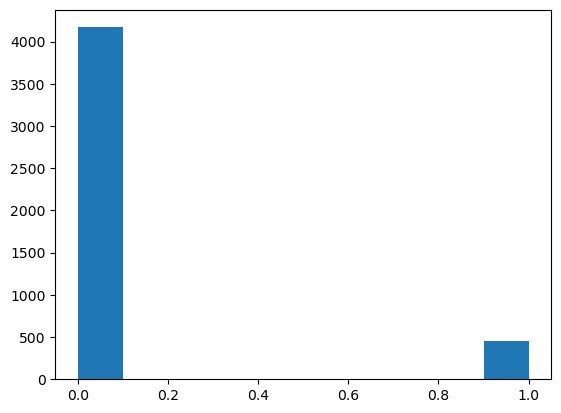

1 0


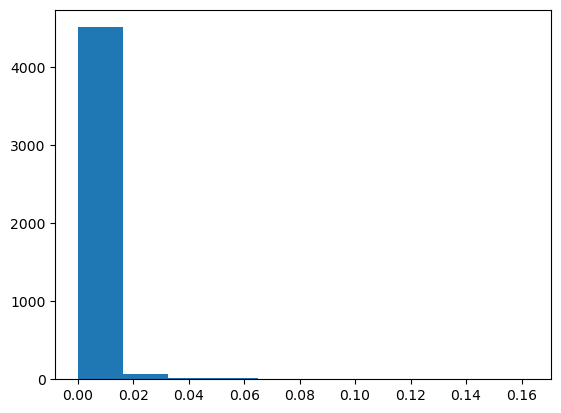

0.162585013952158 0.0


In [24]:
conn = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/shafiei_human_consensus_dataset/01_connectomes/01_consensus_bin_density_10_percent_68.npy")
plt.hist(conn.flatten())
plt.show()
print(conn.flatten().max(), conn.flatten().min())

conn = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/shafiei_human_consensus_dataset/01_connectomes/01_consensus_wei_68.npy")
plt.hist(conn.flatten())
plt.show()
print(conn.flatten().max(), conn.flatten().min())


